In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.datasets import fetch_openml
from sklearn.ensemble import RandomForestClassifier

In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.preprocessing import StandardScaler

In [4]:
import warnings
warnings.filterwarnings('ignore')

In [5]:
print('All libraries imported successfully')

All libraries imported successfully


In [6]:
np.random.seed(66)

In [7]:
from sklearn.datasets import make_classification
from sklearn.preprocessing import LabelEncoder
from collections import Counter

In [8]:
N = 2000
feature_names = ['word_count', 'exclamation_marks', 'links_count', 'sender_known', 'reply_to_mismatch', 'time_of_day',
                'attachment_count', 'caps_ratio', 'unsubscribe_present', 'thread_length']
class_names = ['Work', 'Spam', 'Personal', 'Newsletter', 'Alert']

In [9]:
X, y = make_classification(n_samples=N, n_features=len(feature_names), n_classes=len(class_names), n_clusters_per_class=1, n_informative=3,class_sep=0.8, weights=[0.3, .25, .15, .15, .15])

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True, stratify=y,random_state=47)

In [11]:
Counter(y_train)

Counter({0: 479, 1: 397, 3: 243, 4: 241, 2: 240})

# Class Distribution

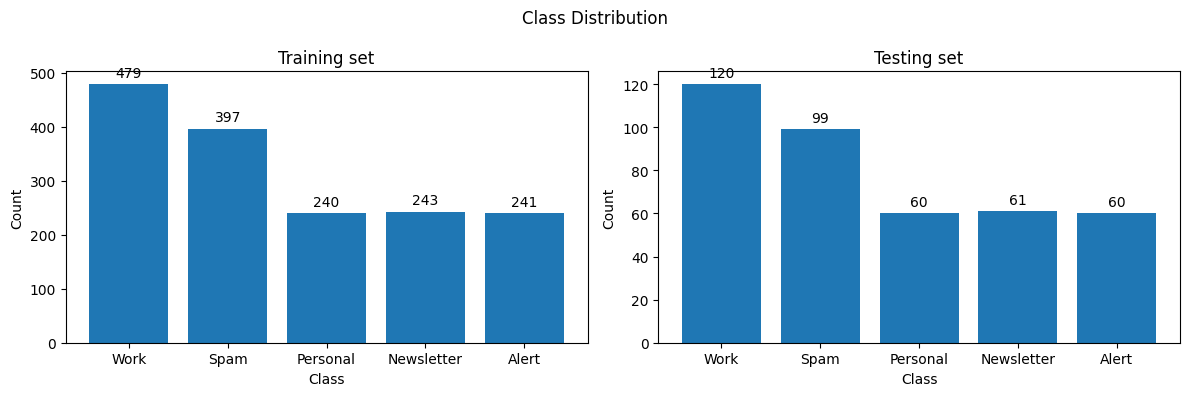

In [12]:
fig, axes= plt.subplots(1,2,figsize=(12,4))
for ax, labels, title in zip(axes, [y_train, y_test], ['Training set', 'Testing set']):
    counts=pd.Series(labels).value_counts().sort_index()
    bars = ax.bar([class_names[i] for i in counts.index], counts.values)
    ax.bar_label(bars, padding=3)
    ax.set(title=title, xlabel='Class', ylabel='Count')

fig.suptitle('Class Distribution')
plt.tight_layout()
plt.show()


In [13]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [14]:
model = LogisticRegression(n_jobs=-1, random_state=47)
model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",47
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [15]:
y_pred_lr = model.predict(X_test_scaled)

In [16]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.62      0.74      0.68       120
           1       0.65      0.66      0.65        99
           2       0.58      0.57      0.57        60
           3       0.57      0.51      0.54        61
           4       0.73      0.53      0.62        60

    accuracy                           0.63       400
   macro avg       0.63      0.60      0.61       400
weighted avg       0.63      0.63      0.62       400



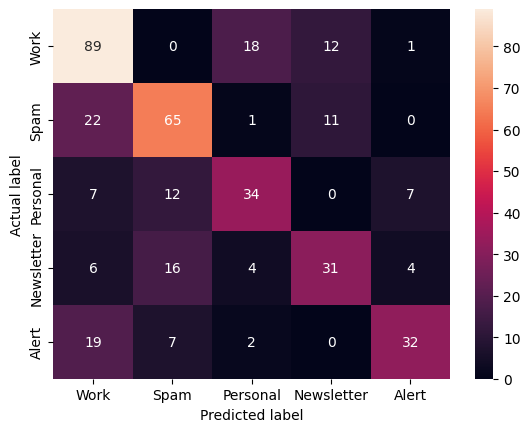

In [17]:
cm = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm, annot=True, xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted label')
plt.ylabel('Actual label')
plt.show()

In [18]:
results_df = pd.DataFrame(X_test, columns=feature_names)
results_df.head()

,word_count,exclamation_marks,links_count,sender_known,reply_to_mismatch,time_of_day,attachment_count,caps_ratio,unsubscribe_present,thread_length
0,-0.904403,-1.256984,0.726717,1.747492,-1.431889,-0.981149,0.367449,-0.529905,-1.080370,0.760221
1,1.622539,-0.118051,0.222832,0.302332,-1.504568,0.411537,-0.487122,0.038656,-0.423498,-0.612880
2,0.018293,0.761596,1.466722,0.282095,-0.911141,-1.027819,-0.159457,-0.392235,-1.377637,0.966925
3,0.974455,-0.812451,-1.394317,0.525195,-0.585821,1.072963,0.175705,1.975522,-2.967280,-1.628863
4,2.550486,-0.550664,2.503619,-0.364614,-0.038957,-1.184600,-0.609586,0.890544,-0.608336,0.164764


In [19]:
y_test[:5]

array([3, 2, 1, 0, 1])

In [20]:
results_df['True_label'] = [class_names[i] for i in y_test]
results_df['Predicted_label'] = [class_names[i] for i in y_pred_lr]
results_df['Correct'] = results_df['True_label'] == results_df['Predicted_label'] 


In [21]:
failure = results_df[results_df['Correct'] == False].copy()

In [22]:
len(failure)

149

In [23]:
failure_rate = len(failure)/len(results_df) * 100
failure_rate = round(failure_rate, 3)
print(f'Failure_rate: {failure_rate}%')

Failure_rate: 37.25%


In [24]:
confusion_pairs = failure.groupby(['True_label', 'Predicted_label']).size().reset_index(name='index')

In [25]:
confusion_pairs

,True_label,Predicted_label,index
0,Alert,Personal,2
1,Alert,Spam,7
2,Alert,Work,19
3,Newsletter,Alert,4
4,Newsletter,Personal,4
5,Newsletter,Spam,16
6,Newsletter,Work,6
7,Personal,Alert,7
8,Personal,Spam,12
9,Personal,Work,7


In [26]:
sorted_conf=confusion_pairs.sort_values('index', ascending=False)
sorted_conf

,True_label,Predicted_label,index
12,Spam,Work,22
2,Alert,Work,19
15,Work,Personal,18
5,Newsletter,Spam,16
8,Personal,Spam,12
14,Work,Newsletter,12
10,Spam,Newsletter,11
1,Alert,Spam,7
7,Personal,Alert,7
9,Personal,Work,7


In [27]:
worst = confusion_pairs.iloc[0]

In [28]:
worst

True_label            Alert
Predicted_label    Personal
index                     2
Name: 0, dtype: object

In [29]:
true_cls = worst['True_label']
pred_cls = worst['Predicted_label']

In [30]:
pair_df = results_df[results_df['True_label'].isin([true_cls, pred_cls])]
pair_df.head(3)

,word_count,exclamation_marks,links_count,sender_known,reply_to_mismatch,time_of_day,attachment_count,caps_ratio,unsubscribe_present,thread_length,True_label,Predicted_label,Correct
1,1.622539,-0.118051,0.222832,0.302332,-1.504568,0.411537,-0.487122,0.038656,-0.423498,-0.612880,Personal,Personal,True
5,1.459237,0.596280,-0.633100,3.008842,-2.184458,-0.654831,1.619913,1.483224,-0.532322,-2.671402,Personal,Work,False
9,0.754661,-1.816919,-2.941915,-0.707227,-0.973062,2.386698,0.035311,0.342326,0.343415,-2.264246,Personal,Personal,True


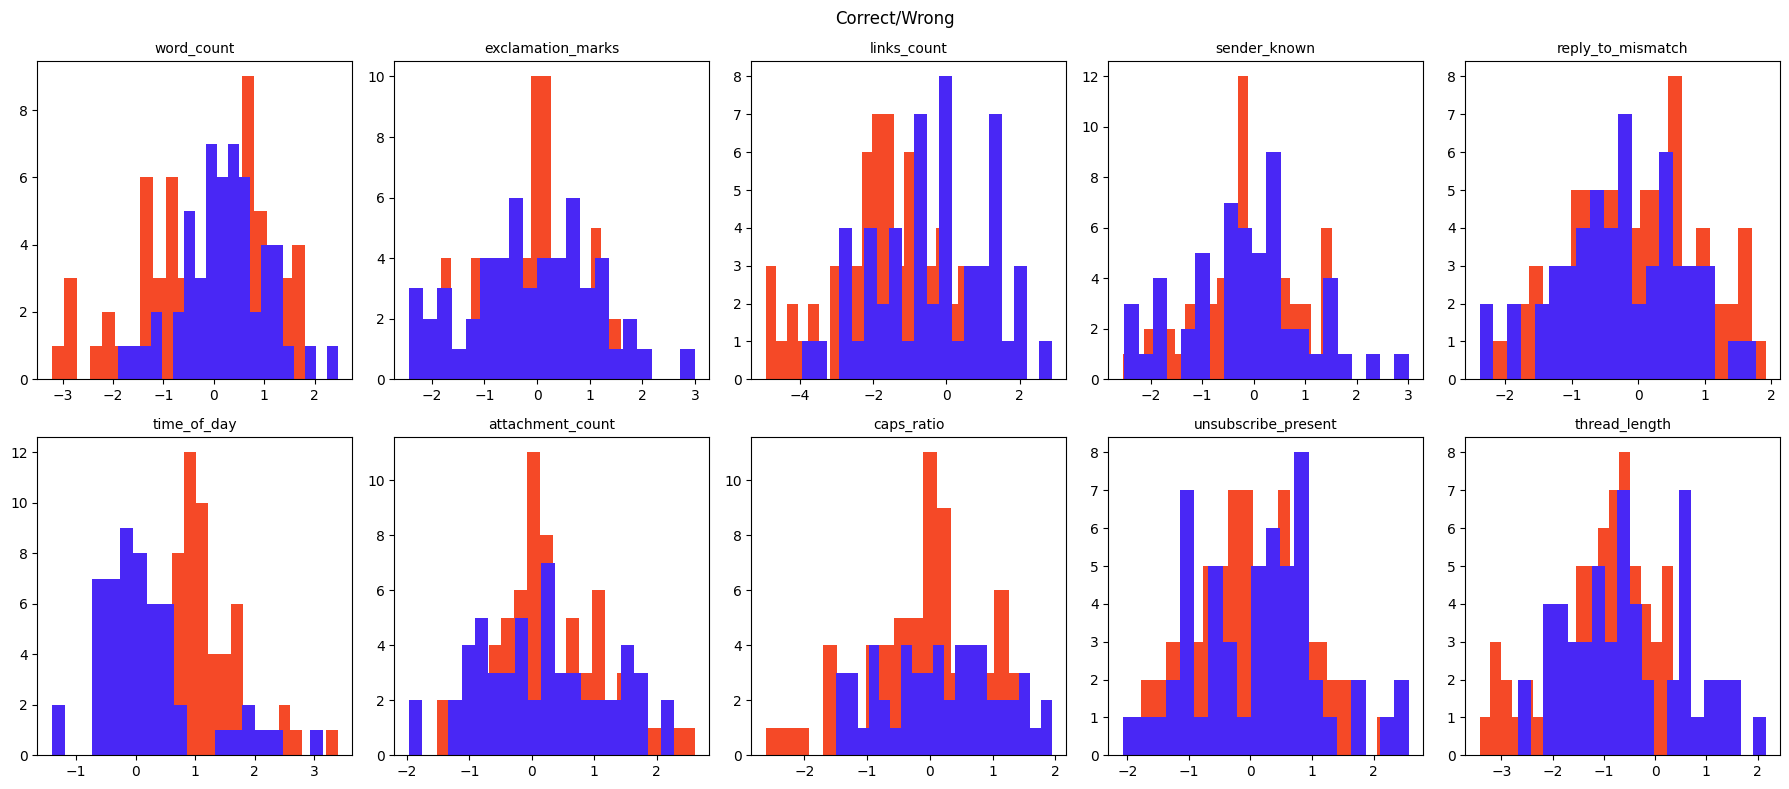

In [31]:
fig, axes= plt.subplots(2,5,figsize=(18,8))
for ax, feat in zip(axes.flat, feature_names):
    for is_correct, color, label in [(True, '#F54927', 'Correct'), (False, '#4927F5', 'wrong')]:
        ax.hist(pair_df.loc[pair_df['Correct'] == is_correct, feat],
        bins=20, color = color, label=label)
    ax.set_title(feat, fontsize=10)


fig.suptitle('Correct/Wrong')
plt.tight_layout()
plt.show()
